# Machine Learning Models

### Import Libraries

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

import warnings
warnings.simplefilter("ignore")

sns.set_theme(style='whitegrid', palette="pastel")

### Data Preprocessing for Machine Learning Models

In [30]:
df = pd.read_csv('data/animal_dataset_processed.csv')

In [31]:
df

,Animal,Height (cm),Weight (kg),Color,Lifespan (years),Diet,Habitat,Predators,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),Social Structure,Offspring per Birth
0,Aardvark,117.5,52.5,Grey,25.0,Carnivore,"Savannas, Grasslands","Lions, Hyenas",40.0,Africa,Least Concern,Orycteropodidae,225.0,Solitary,1.0
1,Aardwolf,45.0,11.0,Yellow-brown,11.0,Carnivore,"Grasslands, Savannas","Lions, Leopards",27.0,Eastern and Southern Africa,Least Concern,Hyaenidae,90.0,Solitary,3.5
2,African Elephant,290.0,4350.0,Grey,65.0,Herbivore,"Savannas, Forests","Lions, Hyenas",25.0,Africa,Vulnerable,Elephantidae,650.0,Herd-based,1.0
3,African Lion,95.0,185.0,Tan,12.0,Carnivore,"Grasslands, Savannas","Hyenas, Crocodiles",58.0,Africa,Vulnerable,Felidae,101.5,Group-based,3.0
4,African Wild Dog,77.5,27.0,Multicolored,11.0,Carnivore,Savannas,"Lions, Hyenas",56.0,Sub-Saharan Africa,Endangered,Canidae,70.0,Group-based,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
182,Wombat,101.0,27.5,"Brown, Gray",7.5,Herbivore,"Forests, Grasslands","Dingoes, Tasmanian Devils",20.0,Australia,Least Concern,Vombatidae,132.0,Solitary,1.0
183,Yak,150.0,850.0,"Brown, Black",22.5,Herbivore,Mountains,"Snow Leopards, Wolves",24.0,"Himalayas, Central Asia",Least Concern,Bovidae,247.5,Group-based,30.0
184,Yellow-Eyed Penguin,62.5,2.0,"Yellow, White",20.0,Carnivore,Coastal Areas,"Seals, Orcas",25.0,New Zealand,Endangered,Spheniscidae,85.0,Solitary,1.0
185,Zebra,280.0,650.0,"Black, White",22.5,Herbivore,Grasslands,"Lions, Hyenas",25.0,Africa,Least Concern,Equidae,272.5,Group-based,12.5


The columns 'Predators', 'Color', and 'Habitat' contain duplicated values within rows, separated by commas. 
This prevents the direct use of the get_dummies method. The following section addresses this issue.

In [32]:
columns = ['Predators', 'Color', 'Habitat']

for col in columns:
    split_data = df[col].str.split(', ', expand=True).stack()

    unique_values = split_data.unique()
    one_hot_df = pd.get_dummies(split_data).groupby(level=0).sum()
    one_hot_df = one_hot_df.reindex(columns=unique_values, fill_value=0)

    df = df.join(one_hot_df)

df = df.drop(columns=['Habitat', 'Predators','Color'])

In [33]:
df.head()

,Animal,Height (cm),Weight (kg),Lifespan (years),Diet,Average Speed (km/h),Countries Found,Conservation Status,Family,Gestation Period (days),...,Tropical and Subtropical,Himalayan Foothills,Wetlands,Cold Regions,Steppes,North America,Tropical Forests,Australia,Gulf of California,Boreal Forests
0,Aardvark,117.5,52.5,25.0,Carnivore,40.0,Africa,Least Concern,Orycteropodidae,225.0,...,0,0,0,0,0,0,0,0,0,0
1,Aardwolf,45.0,11.0,11.0,Carnivore,27.0,Eastern and Southern Africa,Least Concern,Hyaenidae,90.0,...,0,0,0,0,0,0,0,0,0,0
2,African Elephant,290.0,4350.0,65.0,Herbivore,25.0,Africa,Vulnerable,Elephantidae,650.0,...,0,0,0,0,0,0,0,0,0,0
3,African Lion,95.0,185.0,12.0,Carnivore,58.0,Africa,Vulnerable,Felidae,101.5,...,0,0,0,0,0,0,0,0,0,0
4,African Wild Dog,77.5,27.0,11.0,Carnivore,56.0,Sub-Saharan Africa,Endangered,Canidae,70.0,...,0,0,0,0,0,0,0,0,0,0


Define the features (X) and target (y) for classification.

In [34]:
df = df.sample(frac=1).reset_index(drop=True)
X = df.drop(columns=['Animal', 'Diet'])
y = df['Diet']
X = pd.get_dummies(X)

Use LabelEncoder to encode the target labels and StandardScaler to standardize the feature set.

In [35]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [36]:
X.shape

(187, 421)

Split the data into 90% training and 10% testing sets.\
Use 9-fold cross-validation, ensuring each fold has a 10% validation set.\
Fix the random state to ensure reproducibility and comparability between different models.

In [37]:
random_state = 42

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=random_state, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

kfold = StratifiedKFold(n_splits=9, shuffle=True, random_state=random_state)

### SVM Classifier

Utilize Support Vector Machine (SVM) with a linear kernel, employing 9-fold cross-validation. Report the accuracy on the test set and the mean cross-validation score.

In [38]:
svm_classifier = SVC(kernel='linear')

cv_scores = cross_val_score(svm_classifier, X_train, y_train, cv=kfold, n_jobs=-1)

svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

print("Cross-Validation Scores: ", cv_scores)
print("Mean Cross-Validation Score: ", np.mean(cv_scores))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Cross-Validation Scores:  [0.73684211 0.52631579 0.63157895 0.68421053 0.68421053 0.63157895
 0.61111111 0.77777778 0.72222222]
Mean Cross-Validation Score:  0.6673164392462638
Classification Report: 
              precision    recall  f1-score   support

   Carnivore       0.83      0.50      0.62        10
   Herbivore       0.60      0.60      0.60         5
    Omnivore       0.38      0.75      0.50         4

    accuracy                           0.58        19
   macro avg       0.60      0.62      0.58        19
weighted avg       0.68      0.58      0.59        19



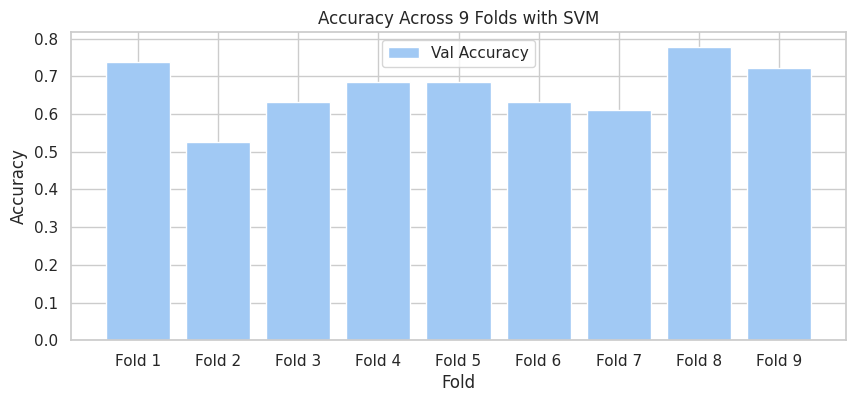

In [39]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, cv_scores, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with SVM')
plt.legend()
plt.show()

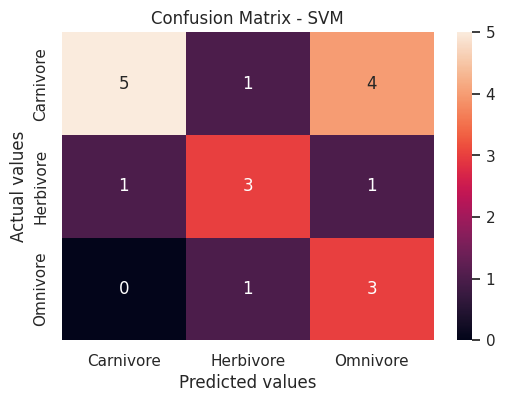

In [40]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

### Random Forest

Utilize Random Forest (RF) with a linear kernel, employing 9-fold cross-validation. Report the accuracy on the test set and the mean cross-validation score.

In [41]:
rf_classifier = RandomForestClassifier(n_estimators=100)

cv_scores = cross_val_score(rf_classifier, X_train, y_train, cv=kfold, n_jobs=-1)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

print("Cross-Validation Scores: ", cv_scores)
print("Mean Cross-Validation Score: ", np.mean(cv_scores))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Cross-Validation Scores:  [0.57894737 0.52631579 0.78947368 0.84210526 0.57894737 0.68421053
 0.61111111 0.66666667 0.55555556]
Mean Cross-Validation Score:  0.648148148148148
Classification Report: 
              precision    recall  f1-score   support

   Carnivore       0.69      0.90      0.78        10
   Herbivore       1.00      0.60      0.75         5
    Omnivore       0.67      0.50      0.57         4

    accuracy                           0.74        19
   macro avg       0.79      0.67      0.70        19
weighted avg       0.77      0.74      0.73        19



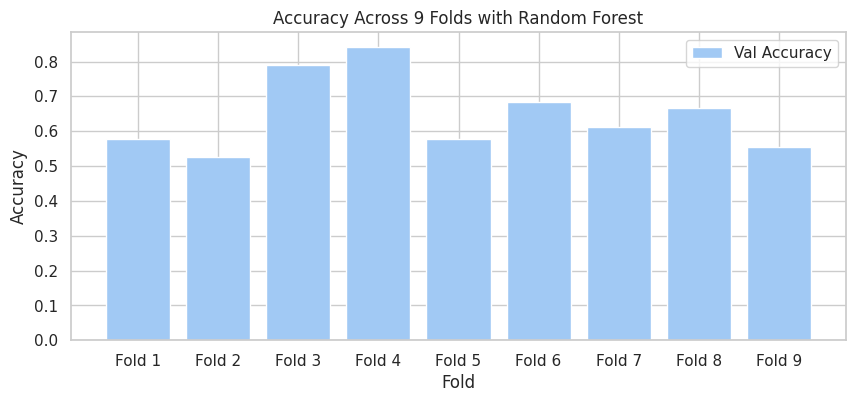

In [42]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, cv_scores, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with Random Forest')
plt.legend()
plt.show()

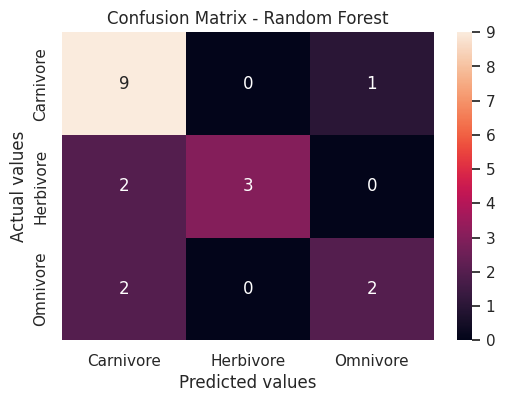

In [43]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

### Logistic Regression

Utilize Logistic Regression (LR) with a linear kernel, employing 9-fold cross-validation. Report the accuracy on the test set and the mean cross-validation score.

In [44]:
lr_classifier = LogisticRegression()

cv_scores = cross_val_score(lr_classifier, X_train, y_train, cv=kfold, n_jobs=-1)

lr_classifier.fit(X_train, y_train)

y_pred = lr_classifier.predict(X_test)

print("Cross-Validation Scores: ", cv_scores)
print("Mean Cross-Validation Score: ", np.mean(cv_scores))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Cross-Validation Scores:  [0.68421053 0.52631579 0.78947368 0.68421053 0.73684211 0.63157895
 0.61111111 0.72222222 0.83333333]
Mean Cross-Validation Score:  0.6910331384015594
Classification Report: 
              precision    recall  f1-score   support

   Carnivore       0.83      0.50      0.62        10
   Herbivore       0.60      0.60      0.60         5
    Omnivore       0.38      0.75      0.50         4

    accuracy                           0.58        19
   macro avg       0.60      0.62      0.58        19
weighted avg       0.68      0.58      0.59        19



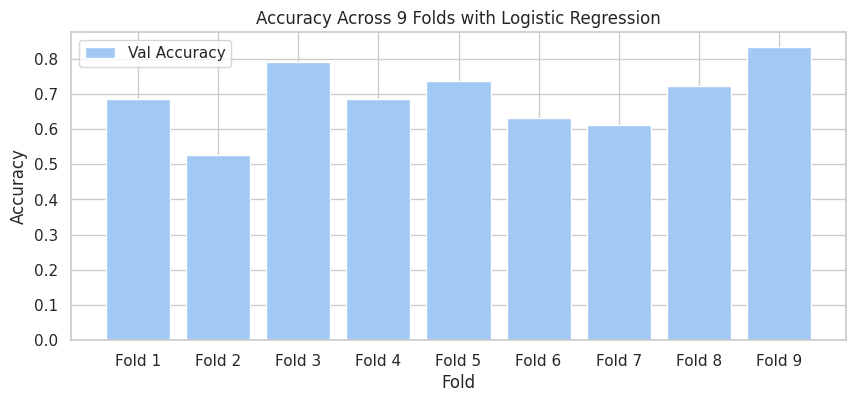

In [45]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, cv_scores, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with Logistic Regression')
plt.legend()
plt.show()

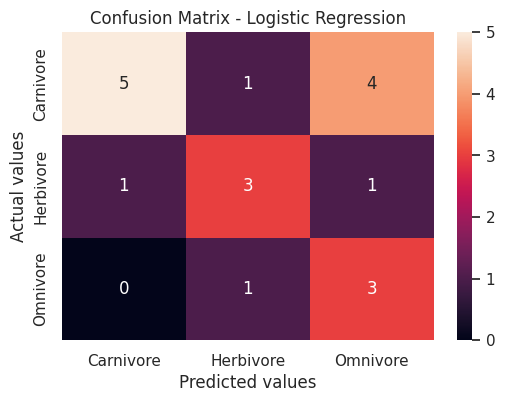

In [46]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

### XGBoost

Utilize XGBoost with a linear kernel, employing 9-fold cross-validation. Report the accuracy on the test set and the mean cross-validation score.

In [47]:
xgbosst_classifier = XGBClassifier()

cv_scores = cross_val_score(xgbosst_classifier, X_train, y_train, cv=kfold, n_jobs=-1)

xgbosst_classifier.fit(X_train, y_train)

y_pred = xgbosst_classifier.predict(X_test)

print("Cross-Validation Scores: ", cv_scores)
print("Mean Cross-Validation Score: ", np.mean(cv_scores))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Cross-Validation Scores:  [0.52631579 0.73684211 0.78947368 0.84210526 0.68421053 0.63157895
 0.77777778 0.61111111 0.61111111]
Mean Cross-Validation Score:  0.6900584795321636
Classification Report: 
              precision    recall  f1-score   support

   Carnivore       1.00      0.60      0.75        10
   Herbivore       0.67      0.80      0.73         5
    Omnivore       0.57      1.00      0.73         4

    accuracy                           0.74        19
   macro avg       0.75      0.80      0.73        19
weighted avg       0.82      0.74      0.74        19



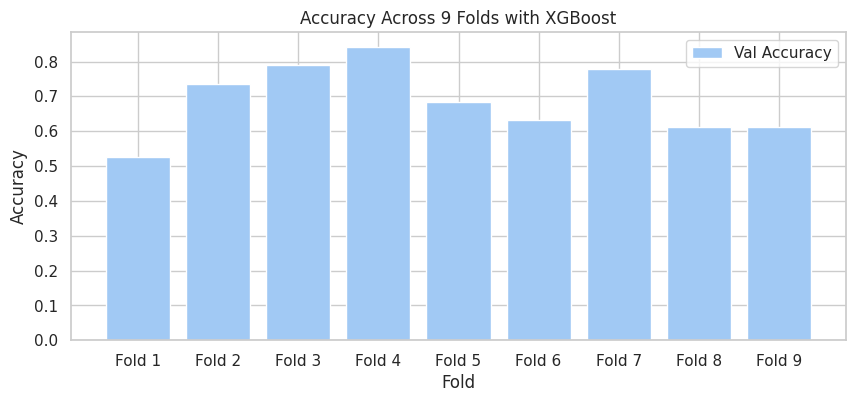

In [48]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, cv_scores, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with XGBoost')
plt.legend()
plt.show()

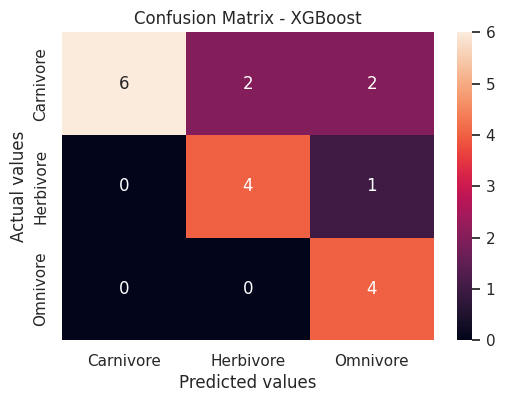

In [49]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

### Neural Network

Utilize Neural Network with a linear kernel, employing 9-fold cross-validation. Report the accuracy on the test set and the mean cross-validation score.

In [50]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2

num_features = X_train.shape[1]
y_categorical = to_categorical(y_train)

train_losses = []
val_losses = []
accuracies = []

for train_index, val_index in kfold.split(X_train, y_train):
    
    X_fold, X_val = X_train[train_index], X_train[val_index]
    y_fold, y_val = y_categorical[train_index], y_categorical[val_index]

    model = Sequential([
        Dense(128, activation='relu', input_shape=(num_features,), kernel_regularizer=l2(0.01)),
        Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(8, activation='relu', kernel_regularizer=l2(0.01)),
        Dense(3, activation='softmax')
    ])

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    
    history = model.fit(X_fold, y_fold, epochs=20, batch_size=32, validation_data=(X_val, y_val), verbose=0)

    _, accuracy = model.evaluate(X_val, y_val)
    accuracies.append(accuracy)

    train_losses.append(history.history['loss'])
    val_losses.append(history.history['val_loss'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4737 - loss: 1.9521
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.4737 - loss: 2.0249
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.5263 - loss: 1.8416
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6842 - loss: 1.7583
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5789 - loss: 1.8263
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.6842 - loss: 1.8344
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6111 - loss: 1.8337
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5556 - loss: 1.8771
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8333 - loss: 1.6066


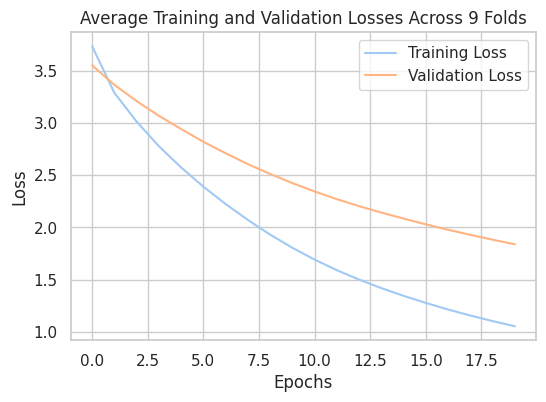

In [51]:
plt.figure(figsize=(6, 4))

avg_train_loss = np.mean(train_losses, axis=0)
avg_val_loss = np.mean(val_losses, axis=0)

plt.plot(avg_train_loss, label='Training Loss')
plt.plot(avg_val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Average Training and Validation Losses Across 9 Folds')
plt.legend()
plt.grid(True)
plt.show()

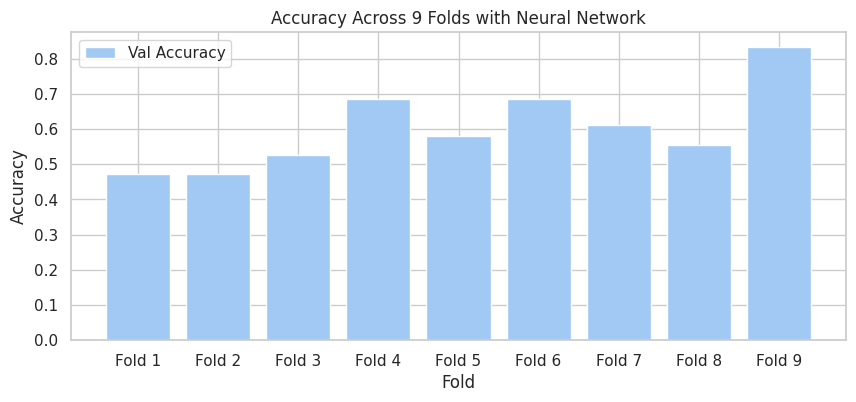

In [52]:
plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(labels, accuracies, label='Val Accuracy')
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy Across 9 Folds with Neural Network')
plt.legend()
plt.show()

In [53]:
y_pred = model.predict(X_test).argmax(axis=1)

print("Cross-Validation Scores: ", accuracies)
print("Mean Cross-Validation Score: ", np.mean(accuracies))
print("Classification Report: ")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Cross-Validation Scores:  [0.4736842215061188, 0.4736842215061188, 0.5263158082962036, 0.6842105388641357, 0.5789473652839661, 0.6842105388641357, 0.6111111044883728, 0.5555555820465088, 0.8333333134651184]
Mean Cross-Validation Score:  0.6023391882578532
Classification Report: 
              precision    recall  f1-score   support

   Carnivore       0.89      0.80      0.84        10
   Herbivore       1.00      0.80      0.89         5
    Omnivore       0.50      0.75      0.60         4

    accuracy                           0.79        19
   macro avg       0.80      0.78      0.78        19
weighted avg       0.84      0.79      0.80        19



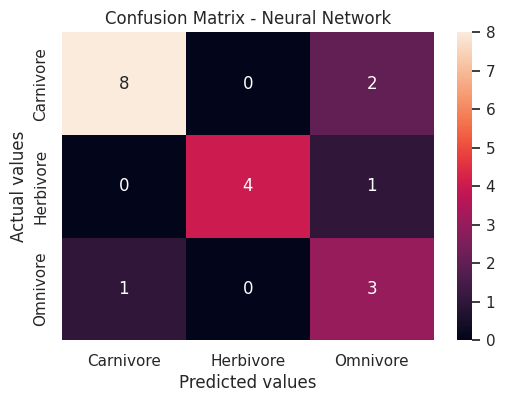

In [54]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - Neural Network')
plt.xlabel('Predicted values')
plt.ylabel('Actual values')
plt.show()

### Comparison of accuracy among different machine learning algorithms on test data.

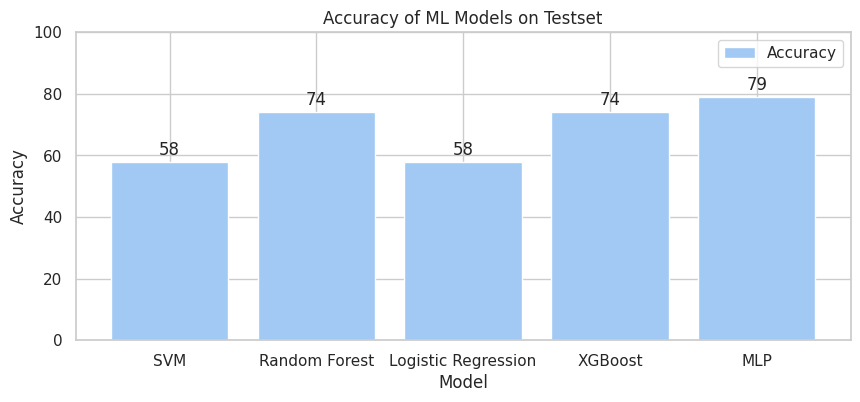

In [57]:
models_accuracy = {
    'SVM' : 58,
    'Random Forest' : 74,
    'Logistic Regression' : 58,
    'XGBoost' : 74,
    'MLP' : 79
}

plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(models_accuracy.keys(), models_accuracy.values(), label='Accuracy')
plt.ylim(0, 100)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Accuracy of ML Models on Testset')

for i, value in enumerate(models_accuracy.values()):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')

plt.legend()
plt.show()

Due to the presence of imbalanced datasets in the target variables, the macro average metric is a fairer evaluation measure.

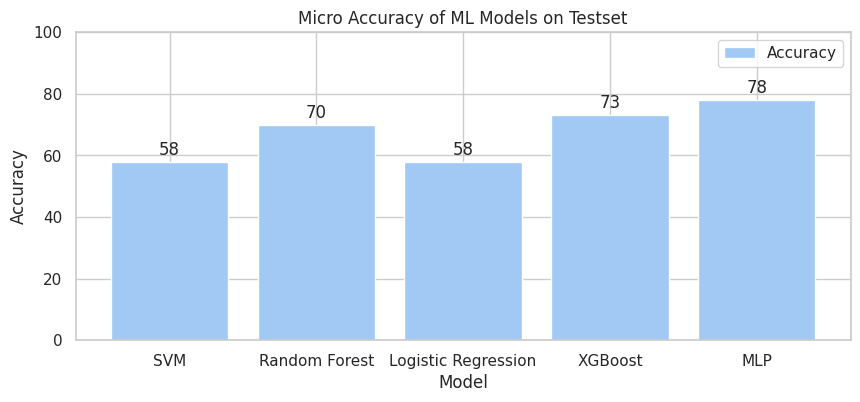

In [58]:
models_accuracy = {
    'SVM' : 58,
    'Random Forest' : 70,
    'Logistic Regression' : 58,
    'XGBoost' : 73,
    'MLP' : 78
}

plt.figure(figsize=(10, 4))

labels = [f'Fold {i}' for i in range(1, 10)]
plt.bar(models_accuracy.keys(), models_accuracy.values(), label='Accuracy')
plt.ylim(0, 100)
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Micro Accuracy of ML Models on Testset')

for i, value in enumerate(models_accuracy.values()):
    plt.text(i, value + 1, str(value), ha='center', va='bottom')

plt.legend()
plt.show()